# Fat-Tree network builder

This notebook shows how to use `get_network_fat_tree`, the builder that generates a
Fat-Tree data-center topology (Al-Fares et al., SIGCOMM 2008) as a native `Network`,
and uses it to study how traffic spreads over the topology.

A Fat-Tree with an even parameter `k` has `k` pods. Each pod contains `k/2` edge and
`k/2` aggregation switches, fully connected to each other; each edge switch serves
`k/2` hosts, and each aggregation switch connects to `k/2` of the `(k/2)²` core
switches.

| Tier | Nodes | Count |
|---|---|---|
| core | `core_<i>` | `(k/2)²` |
| aggregation | `agg_<pod>_<a>` | `k²/2` |
| edge | `edge_<pod>_<e>` | `k²/2` |
| host | `host_<pod>_<e>_<h>` | `k³/4` |

Every node has the attribute `tier` (and `pod`, except the core switches), and every
link has the attribute `link_class`: `access` (host–edge), `aggregation`
(edge–aggregation) or `core` (aggregation–core). Bandwidth and length can be set
once for every link or per link class.

## Setup

In [1]:
import json
import os
import random
import time

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

from eclypse.builders.network import get_network_fat_tree
from eclypse.network import (
    NetworkApplication,
    PacketGenerationEvent,
    RoutingEvent,
    RoutingMetric,
)
from eclypse.network.network import path_algorithm
from eclypse.placement.strategies import StaticStrategy
from eclypse.simulation import Simulation, SimulationConfig

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Chart style: light surface, recessive axes and grid
SURFACE, TEXT, TEXT_MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID,
    "axes.labelcolor": TEXT_MUTED,
    "axes.titlecolor": TEXT,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "xtick.color": TEXT_MUTED,
    "ytick.color": TEXT_MUTED,
    "legend.frameon": False,
    "legend.labelcolor": TEXT,
    "font.size": 10,
})

# Tiers: one blue ramp (dark = core) plus a distinct marker per tier
TIERS = {
    "core": {"label": "Core switch", "color": "#0d366b", "marker": "H", "size": 260, "y": 3},
    "aggregation": {"label": "Aggregation switch", "color": "#1c5cab", "marker": "s", "size": 150, "y": 2},
    "edge": {"label": "Edge switch", "color": "#3987e5", "marker": "^", "size": 130, "y": 1},
    "host": {"label": "Host", "color": "#86b6ef", "marker": "o", "size": 45, "y": 0},
}
LINK_CLASSES = ["access", "aggregation", "core"]


def fat_tree_layout(net):
    # Layered layout: hosts at the bottom grouped by pod, switches above them
    hosts = sorted(net.hosts, key=lambda h: tuple(int(x) for x in h.split("_")[1:]))
    x = {}
    for i, host in enumerate(hosts):
        x[host] = i + 1.5 * net.nodes[host]["pod"]  # gap between pods
    for node, data in net.nodes(data=True):
        if data["tier"] == "edge":
            x[node] = np.mean([x[h] for h in net.successors(node) if h in x and net.nodes[h]["tier"] == "host"])
    for node, data in net.nodes(data=True):
        if data["tier"] == "aggregation":
            pod_edges = [x[e] for e in x if net.nodes[e]["tier"] == "edge" and net.nodes[e]["pod"] == data["pod"]]
            a, half = int(node.split("_")[2]), len(pod_edges)
            lo, hi = min(pod_edges), max(pod_edges)
            x[node] = lo + (hi - lo) * a / max(half - 1, 1)
    cores = sorted((n for n, d in net.nodes(data=True) if d["tier"] == "core"), key=lambda c: int(c.split("_")[1]))
    span = (min(x.values()), max(x.values()))
    for i, core in enumerate(cores):
        x[core] = span[0] + (span[1] - span[0]) * (i + 0.5) / len(cores)
    return {n: (x[n], TIERS[net.nodes[n]["tier"]]["y"]) for n in net.nodes}


def draw_fat_tree(ax, net, pos, edge_colors=None, edge_widths=None):
    # Pod bands in the background
    for pod in sorted({d["pod"] for _, d in net.nodes(data=True) if "pod" in d}):
        xs = [pos[n][0] for n, d in net.nodes(data=True) if d.get("pod") == pod]
        ax.axvspan(min(xs) - 0.6, max(xs) + 0.6, ymin=0.02, ymax=0.72, color=GRID, alpha=0.45 if pod % 2 else 0.2, lw=0)
        ax.text((min(xs) + max(xs)) / 2, -0.55, f"pod {pod}", ha="center", color=TEXT_MUTED, fontsize=9)
    edges = [(u, v) for u, v in net.edges() if u < v]
    nx.draw_networkx_edges(
        net, pos, edgelist=edges, ax=ax, arrows=False,
        edge_color=[edge_colors(e) for e in edges] if edge_colors else TEXT_MUTED,
        width=[edge_widths(e) for e in edges] if edge_widths else 0.8,
        alpha=None if edge_colors else 0.5,
    )
    for tier, style in TIERS.items():
        nodes = [n for n, d in net.nodes(data=True) if d["tier"] == tier]
        nx.draw_networkx_nodes(net, pos, nodelist=nodes, ax=ax, node_color=style["color"],
                               node_shape=style["marker"], node_size=style["size"],
                               edgecolors=SURFACE, linewidths=1.0)
    ax.set_ylim(-0.9, 3.5)
    ax.axis("off")


TIER_HANDLES = [
    Line2D([], [], linestyle="", marker=s["marker"], markersize=9, markerfacecolor=s["color"],
           markeredgecolor=SURFACE, label=s["label"])
    for s in TIERS.values()
]

## 1. Build the network

With the default arguments the builder produces the same network as before: every
link at 1 Gbps and 2 km, queues of 100 packets, 0.1 ms of processing per packet.

In [2]:
K = 6
net = get_network_fat_tree(K, seed=SEED)

print(f"k = {K}: {net.number_of_nodes()} nodes ({len(net.hosts)} hosts, {len(net.routers)} switches), "
      f"{net.number_of_edges() // 2} bidirectional links")
print("Connected:", nx.is_strongly_connected(net))

nodes = pd.Series([d["tier"] for _, d in net.nodes(data=True)]).value_counts().reindex(list(TIERS))
print("\nNodes per tier")
print(nodes.to_string())

links = pd.DataFrame(
    [{"class": d["link_class"], "bandwidth_mbps": d["bandwidth_mbps"], "length_km": d["length_km"]}
     for u, v, d in net.edges(data=True) if u < v]
)
print("\nLinks per class")
print(links.groupby("class").agg(links=("length_km", "size"), bandwidth_mbps=("bandwidth_mbps", "first"),
                                 length_km=("length_km", "first")).reindex(LINK_CLASSES).to_string())

print("\nSize of the topology for other values of k")
sizes = []
for k in (4, 6, 8, 10, 12):
    g = get_network_fat_tree(k)
    sizes.append({"k": k, "hosts": len(g.hosts), "switches": len(g.routers), "links": g.number_of_edges() // 2})
print(pd.DataFrame(sizes).to_string(index=False))

k = 6: 99 nodes (54 hosts, 45 switches), 162 bidirectional links
Connected: True

Nodes per tier
core            9
aggregation    18
edge           18
host           54

Links per class
             links  bandwidth_mbps  length_km
class                                        
access          54          1000.0        2.0
aggregation     54          1000.0        2.0
core            54          1000.0        2.0

Size of the topology for other values of k
 k  hosts  switches  links
 4     16        20     48
 6     54        45    162
 8    128        80    384
10    250       125    750
12    432       180   1296


## 2. Draw the network

Hosts are at the bottom, grouped by pod; above them the edge, aggregation and core
switches.

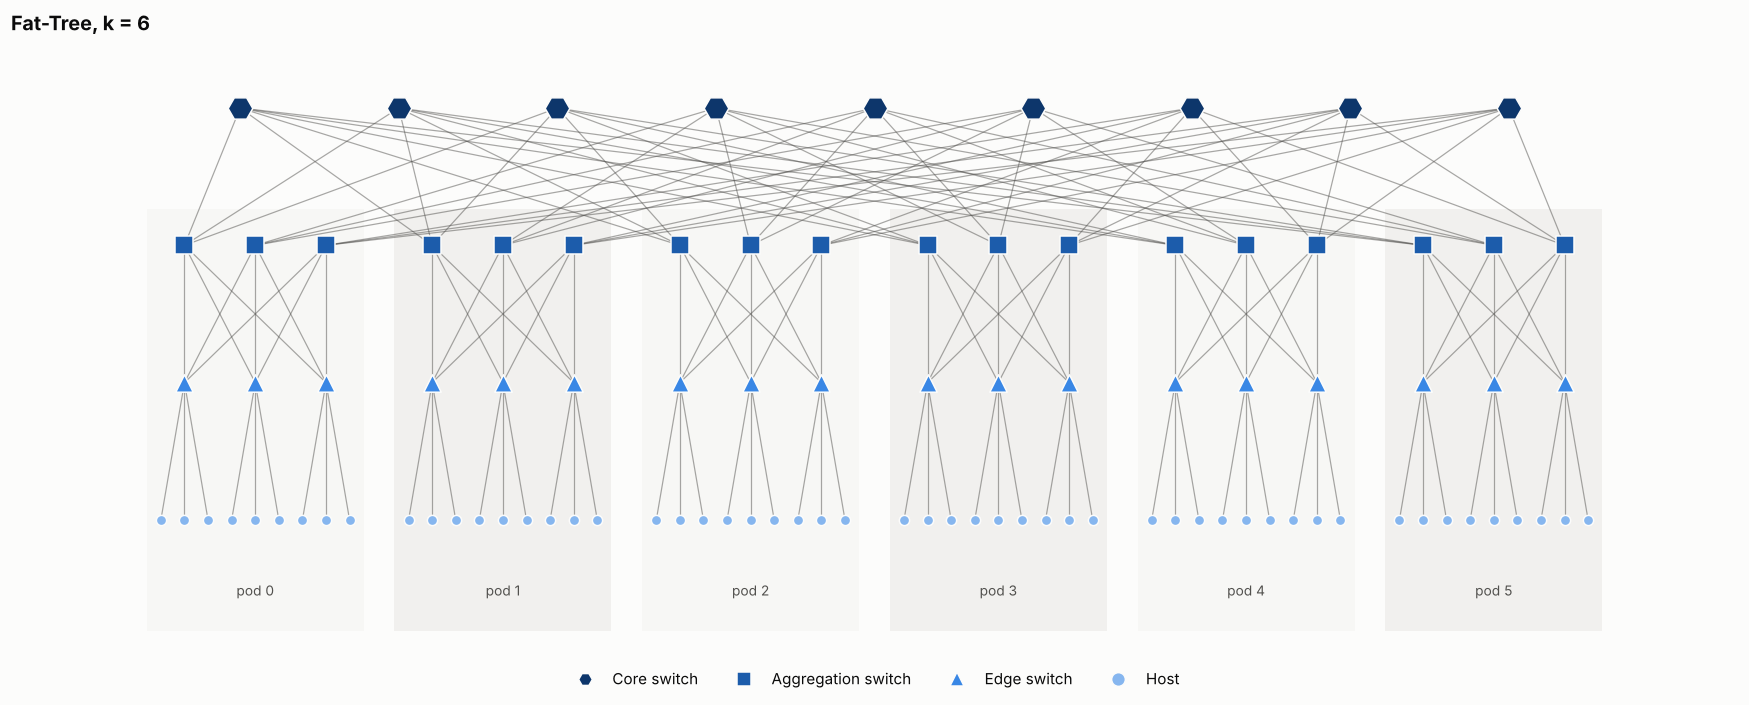

In [3]:
pos = fat_tree_layout(net)

fig, ax = plt.subplots(figsize=(16, 6.5))
draw_fat_tree(ax, net, pos)
ax.set_title(f"Fat-Tree, k = {K}", loc="left")
ax.legend(handles=TIER_HANDLES, loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=4)
fig.tight_layout()
plt.show()

## 3. Path diversity and single-path routing

Between two hosts of different pods a Fat-Tree offers `(k/2)²` equal-cost paths, one
through each core switch. `Network` routes every packet on a single minimum-cost path
(there is no ECMP), so the traffic does not spread over this diversity.

We build a *permutation* traffic pattern, the classic data-center benchmark: every
host sends to one host of a different pod and receives from exactly one host. The
map shows how many of these flows cross each link: since equal-cost paths are tied,
the routing picks the same core switch for every pair of pods, and all the traffic
between pods crosses a single core switch.

Equal-cost paths host_0_0_0 -> host_5_0_0: 9
Aggregation -> core uplinks used: 6 of 54, all towards core_0
Flows per used uplink: [9] (with ideal ECMP: 1)


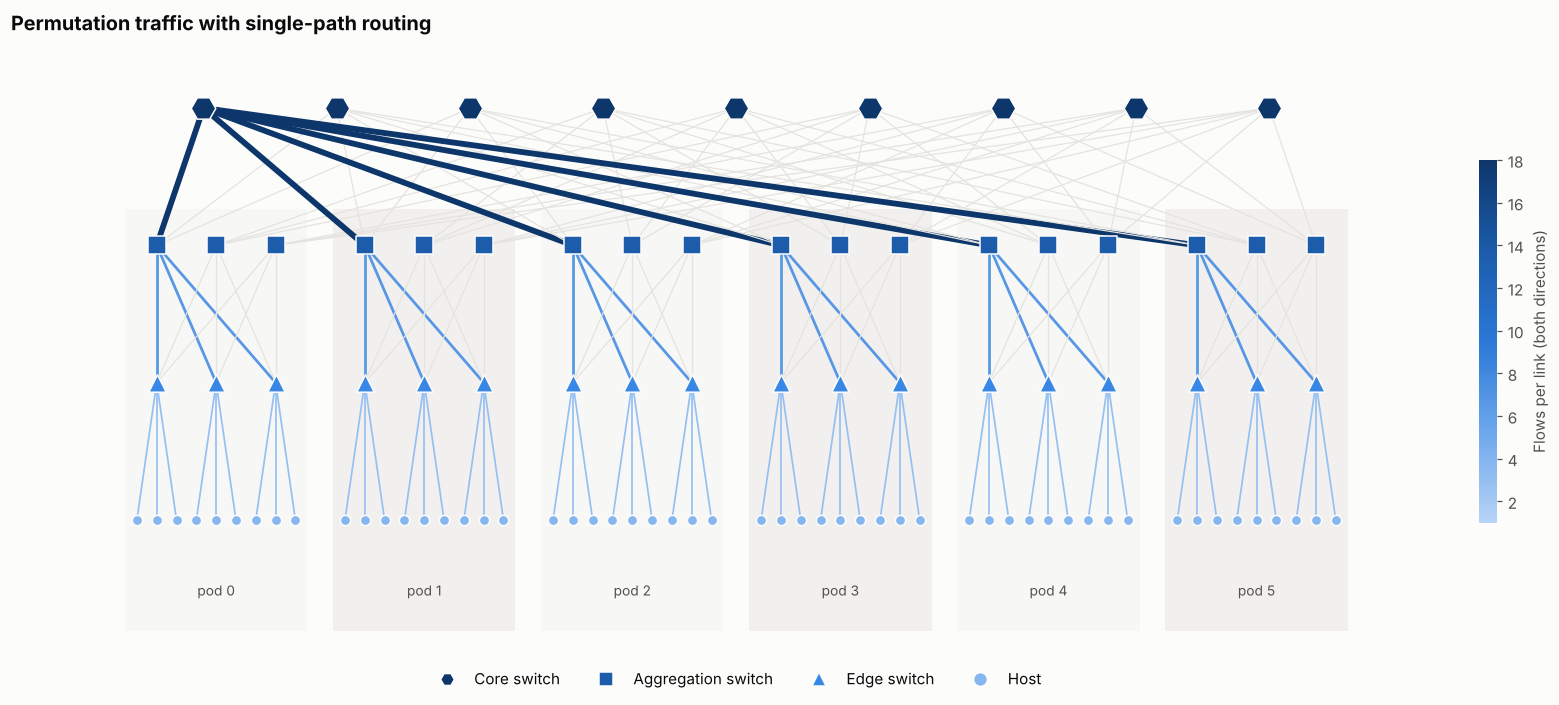

In [4]:
hosts = net.hosts
src = "host_0_0_0"
dst = next(h for h in hosts if net.nodes[h]["pod"] == K - 1)
print(f"Equal-cost paths {src} -> {dst}: {len(list(nx.all_shortest_paths(net, src, dst)))}")

perm_rng = random.Random(SEED)
while True:
    targets = hosts[:]
    perm_rng.shuffle(targets)
    if all(net.nodes[a]["pod"] != net.nodes[b]["pod"] for a, b in zip(hosts, targets)):
        break
flows = list(zip(hosts, targets))

directed = {}        # flows per directed link
flows_per_link = {}  # flows per link, both directions
for a, b in flows:
    path = path_algorithm(net, a, b)
    for u, v in zip(path, path[1:]):
        directed[(u, v)] = directed.get((u, v), 0) + 1
        key = tuple(sorted((u, v)))
        flows_per_link[key] = flows_per_link.get(key, 0) + 1

uplinks = [(u, v) for u, v, d in net.edges(data=True)
           if d["link_class"] == "core" and net.nodes[u]["tier"] == "aggregation"]
used = [e for e in uplinks if e in directed]
cores = sorted({v for _, v in used})
print(f"Aggregation -> core uplinks used: {len(used)} of {len(uplinks)}, all towards {', '.join(cores)}")
print(f"Flows per used uplink: {sorted({directed[e] for e in used})} "
      f"(with ideal ECMP: {len(flows) / len(uplinks):.0f})")

ramp = LinearSegmentedColormap.from_list("blue_ramp", ["#b7d3f6", "#6da7ec", "#2a78d6", "#1c5cab", "#0d366b"])
peak = max(flows_per_link.values())

fig, ax = plt.subplots(figsize=(16, 6.5))
draw_fat_tree(
    ax, net, pos,
    edge_colors=lambda e: ramp(flows_per_link[e] / peak) if e in flows_per_link else GRID,
    edge_widths=lambda e: 0.8 + 3.0 * flows_per_link.get(e, 0) / peak,
)
colorbar = fig.colorbar(plt.cm.ScalarMappable(norm=plt.Normalize(1, peak), cmap=ramp), ax=ax, shrink=0.6, pad=0.01)
colorbar.set_label("Flows per link (both directions)", color=TEXT_MUTED)
colorbar.outline.set_visible(False)
ax.set_title("Permutation traffic with single-path routing", loc="left")
ax.legend(handles=TIER_HANDLES, loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=4)
fig.tight_layout()
plt.show()

## 4. Simulate the permutation traffic

Each flow sends 30 packets of 1500 bytes per step of 2 ms (180 Mbps, 18% of a host
link). The concentrated core uplinks then receive more traffic than 1 Gbps can carry.
We compare two versions of the same network:

- **uniform**: every link at 1 Gbps;
- **fast core**: the aggregation–core links at 10 Gbps, using the per-class
  `bandwidth_mbps` argument.

Queues hold 1000 packets: with one hop per step, all the packets that reach a link in
a step arrive together, so the queue must hold a step's worth of arrivals, otherwise
packets are dropped even if the link could transmit them within the step.

In [5]:
def simulate(name, bandwidth_mbps, steps=100):
    network = get_network_fat_tree(K, bandwidth_mbps=bandwidth_mbps, max_queue_size=1000, seed=SEED)
    app = NetworkApplication(f"Permutation_{name}")
    mapping = {}
    for host in network.hosts:
        mapping[f"svc_{host}"] = host
        app.add_node(f"svc_{host}", cpu=1, ram=1)
    for a, b in flows:
        app.add_edge(f"svc_{a}", f"svc_{b}", packet_size_bytes=1500, avg_packets_per_step=30)

    config = SimulationConfig(
        seed=SEED,
        max_steps=steps,
        path=f"./results_fat_tree/{name}",
        events=[PacketGenerationEvent(), RoutingEvent(step_duration_s=0.002), RoutingMetric()],
        include_default_metrics=False,
        report_format="json",
        report_backend="pandas",
        log_level="ERROR",
        remote=False,
    )
    sim = Simulation(network, simulation_config=config)
    sim.register(app, placement_strategy=StaticStrategy(mapping))
    start = time.perf_counter()
    sim.start()
    sim.wait()
    elapsed = time.perf_counter() - start

    frames = []
    with open(os.path.join(config.path, "json", "application.jsonl")) as file:
        for line in file:
            record = json.loads(line)
            if record.get("callback_name") == "traffic_routing":
                columns = {c: v for _, c, v in (m for m in record["data"] if len(m) == 3)}
                if columns:
                    frames.append(pd.DataFrame(columns))
    hops = pd.concat(frames, ignore_index=True)
    hops["link_class"] = [network.edges[tuple(h.split("->"))]["link_class"] for h in hops["hop"]]
    hops["scenario"] = name
    packets = hops["packet_id"].nunique()
    print(f"{name:>9}: {len(hops)} hops in {elapsed:.2f} s, "
          f"{network.dropped_packets} of {packets} packets dropped ({network.dropped_packets / packets:.1%})")
    return hops


results = pd.concat(
    [simulate("uniform", 1000), simulate("fast core", {"core": 10_000})],
    ignore_index=True,
)

  uniform: 775143 hops in 6.33 s, 56245 of 160368 packets dropped (35.1%)
fast core: 939158 hops in 7.11 s, 0 of 160519 packets dropped (0.0%)


## 5. Results

With uniform 1 Gbps links, the six uplinks towards the single core switch in use are
overloaded: their queues fill up and about a third of all the packets are dropped
there (in the table, the drop rate of the `core` class counts both directions, while
drops happen only on the uplinks). With 10 Gbps core links the same traffic flows
without losses.

                         hops  dropped_%  mean_queue_ms  max_queue_ms
scenario  link_class                                                 
fast core access       313038        0.0           0.18          0.60
          aggregation  313004        0.0           0.54          1.45
          core         313116        0.0           0.16          0.38
uniform   access       258841        0.0           0.16          0.59
          aggregation  258195        0.0           0.47          1.52
          core         258107       21.6          10.02         11.99


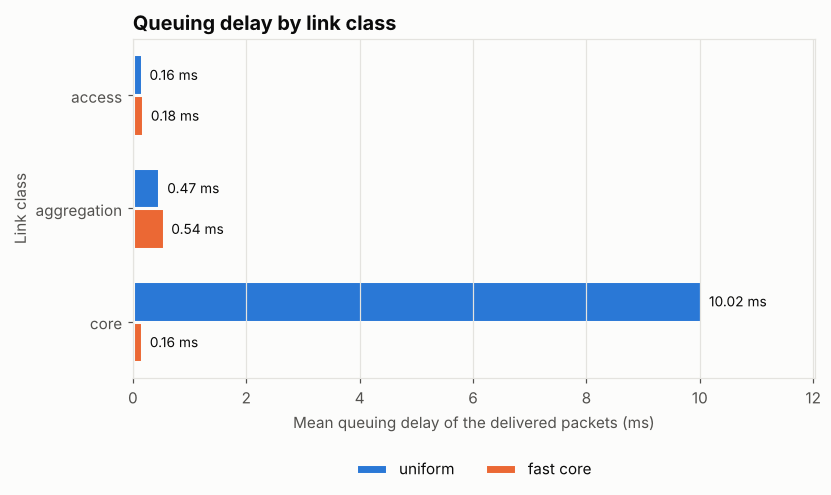

In [6]:
by = ["scenario", "link_class"]
delivered = results[~results["dropped"]]
summary = pd.DataFrame({
    "hops": results.groupby(by).size(),
    "dropped_%": (100 * results.groupby(by)["dropped"].mean()).round(1),
    "mean_queue_ms": delivered.groupby(by)["queue_ms"].mean().round(2),
    "max_queue_ms": delivered.groupby(by)["queue_ms"].max().round(2),
}).reindex(LINK_CLASSES, level="link_class")
print(summary.to_string())

SCENARIOS = {"uniform": "#2a78d6", "fast core": "#eb6834"}
queue = (delivered.groupby(["link_class", "scenario"])["queue_ms"].mean()
         .unstack().reindex(LINK_CLASSES))

fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(LINK_CLASSES))
height = 0.36
for i, (scenario, color) in enumerate(SCENARIOS.items()):
    values = queue[scenario].to_numpy()
    bars = ax.barh(y + (i - 0.5) * height, values, height=height, color=color,
                   edgecolor=SURFACE, linewidth=2, label=scenario)
    for bar, value in zip(bars, values):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f"  {value:.2f} ms",
                va="center", color=TEXT, fontsize=9)
ax.set_yticks(y, LINK_CLASSES)
ax.invert_yaxis()
ax.set_xlim(0, queue.to_numpy().max() * 1.2)
ax.set_xlabel("Mean queuing delay of the delivered packets (ms)")
ax.set_ylabel("Link class")
ax.set_title("Queuing delay by link class", loc="left")
ax.grid(axis="y", visible=False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2)
plt.show()

## Notes

- **No ECMP.** Real Fat-Trees spread flows over the `(k/2)²` equal-cost paths (ECMP
  or flow hashing). `Network` uses one minimum-cost path per destination, so the core
  is under-used and a few links become hotspots, as shown above.
- **Queue size and step duration.** With one hop per step, the packets that reach a
  link in the same step arrive together. Choose `max_queue_size` larger than the
  packets a link can receive in one step, otherwise drops reflect this burst rather
  than a lack of capacity.
- **Long queues.** When a queue holds more work than one step (here up to about 12 ms
  on the overloaded uplinks, with steps of 2 ms), the computed delays are still
  correct, but the packet moves to the next hop at the next step anyway.